# Speech Emotion Recognition — Log-Mel + ResNet34 Pipeline (v2)

**Changes from v1:**
- ✓ Fixed normalization: compute mean/std from training set (not ImageNet)
- ✓ Removed image augmentation (no RandomAffine, ColorJitter)
- ✓ Refactored training into reusable `finetune()` function
- ✓ Better learning rate schedule (CosineAnnealingLR)
- ✓ Cleaner code structure

In [1]:
import os
import re
import random

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from prettytable import PrettyTable

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet34, ResNet34_Weights, densenet121, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# ── Paths ──────────────────────────────────────────────────────────────────
RAVDESS_PATH = "../../data/ravdess"
SAVEE_PATH   = "../../data/savee"

# ── Emotion mappings ───────────────────────────────────────────────────────
emotion_to_label = {
    "neutral": 0, "calm": 1, "happy": 2, "sad": 3,
    "angry": 4, "fear": 5, "disgust": 6, "surprise": 7
}
ravdess_code_to_emotion = {
    "01": "neutral", "02": "calm",    "03": "happy",
    "04": "sad",     "05": "angry",   "06": "fear",
    "07": "disgust", "08": "surprise"
}
savee_code_to_emotion = {
    "a": "angry", "d": "disgust", "f": "fear",
    "h": "happy", "n": "neutral", "sa": "sad", "su": "surprise"
}

# ── Feature params ─────────────────────────────────────────────────────────
SAMPLE_RATE = 16000
N_MELS      = 128
N_FFT       = 1024
HOP_LENGTH  = 512
IMG_SIZE    = 128   # spectrogram resized to IMG_SIZE × IMG_SIZE

# ── Training params ────────────────────────────────────────────────────────
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 1e-3
NUM_CLASSES = len(emotion_to_label)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Config : {BATCH_SIZE=}  {EPOCHS=}  {LR=}")

Device : cuda
Config : BATCH_SIZE=64  EPOCHS=30  LR=0.001


## 1 · Load Metadata (RAVDESS + SAVEE)

In [2]:
records = []
for actor in os.listdir(RAVDESS_PATH):
    for fn in os.listdir(f"{RAVDESS_PATH}/{actor}"):
        if not fn.endswith(".wav"):
            continue
        parts   = fn.replace(".wav", "").split("-")
        emotion = ravdess_code_to_emotion[parts[2]]
        records.append({"path": f"{RAVDESS_PATH}/{actor}/{fn}",
                         "emotion": emotion, "label": emotion_to_label[emotion],
                         "dataset": "RAVDESS"})
ravdess_df = pd.DataFrame(records)
print(f"RAVDESS : {len(ravdess_df)} samples")
print(ravdess_df["emotion"].value_counts())

RAVDESS : 1440 samples
emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64


In [3]:
records = []
for fn in os.listdir(SAVEE_PATH):
    if not fn.lower().endswith(".wav"):
        continue
    speaker, ep = os.path.splitext(fn)[0].split("_")
    code        = re.match(r"[a-z]+", ep).group()  # type: ignore
    emotion     = savee_code_to_emotion[code]
    records.append({"path": f"{SAVEE_PATH}/{fn}",
                     "emotion": emotion, "label": emotion_to_label[emotion],
                     "dataset": "SAVEE"})
savee_df = pd.DataFrame(records).sort_values("path").reset_index(drop=True)
print(f"SAVEE   : {len(savee_df)} samples")
print(savee_df["emotion"].value_counts())

SAVEE   : 480 samples
emotion
neutral     120
angry        60
disgust      60
fear         60
happy        60
sad          60
surprise     60
Name: count, dtype: int64


Combined: (1920, 4)


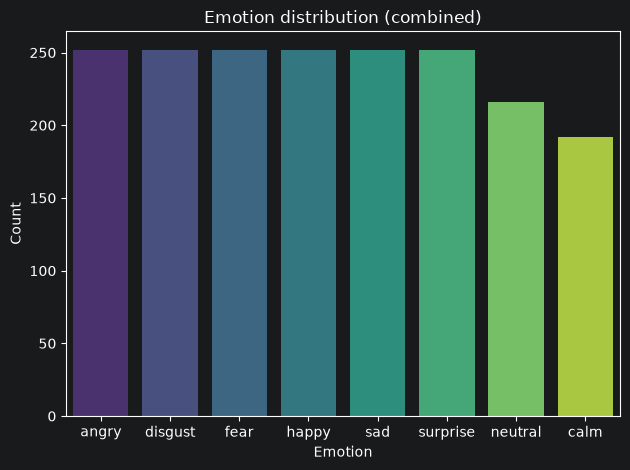

In [4]:
combined_df = pd.concat([savee_df, ravdess_df], ignore_index=True)
print(f"Combined: {combined_df.shape}")
os.makedirs("CSVs", exist_ok=True)
combined_df.to_csv("CSVs/combined_metadata.csv", index=False)

counts = combined_df["emotion"].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette="viridis", legend=False)
plt.title("Emotion distribution (combined)")
plt.xlabel("Emotion"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

## 2 · Feature Extraction Helpers

Log-mel spectrogram → [0, 1] normalization → 3-channel image (repeat grayscale)

In [5]:
def extract_logmelspec(path, sample_rate=SAMPLE_RATE,
                        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Load audio → log-mel spectrogram (N_MELS, T) in dB."""
    audio, sr = librosa.load(path, sr=sample_rate)
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    return librosa.power_to_db(mel, ref=np.max)  # (N_MELS, T)


def pad_or_trim(spec, max_steps=IMG_SIZE):
    """Pad or trim the time axis so spec has exactly max_steps frames."""
    T = spec.shape[1]
    if T >= max_steps:
        return spec[:, :max_steps]
    return np.pad(spec, ((0, 0), (0, max_steps - T)), mode="constant")


def spec_to_tensor(spec):
    """(N_MELS, T) → (3, N_MELS, T) normalized float32 tensor.

    Normalize to [0, 1], then repeat to 3 channels for RGB compatibility.
    """
    # Normalize spec to [0, 1] (spec is in dB, typically [-80, 0])
    spec_min, spec_max = spec.min(), spec.max()
    img = (spec - spec_min) / (spec_max - spec_min + 1e-8)
    
    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1, H, W)
    return img.repeat(3, 1, 1)                                  # (3, H, W)

## 3 · Extract Log-Mel Spectrograms

In [6]:
spec_list, label_list = [], []
for _, row in tqdm(combined_df.iterrows(), total=len(combined_df),
                   desc="Extracting"):
    spec = pad_or_trim(extract_logmelspec(row["path"]))
    spec_list.append(spec)
    label_list.append(row["label"])

labels = np.array(label_list)
print(f"\n✓ {len(spec_list)} samples  |  shape: {spec_list[0].shape}")

Extracting: 100%|██████████| 1920/1920 [00:40<00:00, 47.54it/s]


✓ 1920 samples  |  shape: (128, 128)


## 4 · Train / Val / Test Split (80 / 10 / 10)

In [7]:
X_tv, X_test, y_tv, y_test = train_test_split(
    spec_list, labels, test_size=0.1, random_state=42, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.111, random_state=42, stratify=y_tv
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")

Train: 1536  |  Val: 192  |  Test: 192


## 5 · Compute Normalization Stats from Training Set

Tính mean/std từ training set (không dùng ImageNet stats)

In [8]:
def compute_dataset_stats(spec_list):
    """Compute mean & std of all normalized spectrograms."""
    all_pixels = []
    for spec in tqdm(spec_list, desc="Computing stats"):
        img = spec_to_tensor(spec)  # (3, H, W), normalized to [0, 1]
        all_pixels.append(img.flatten())
    
    all_pixels = torch.cat(all_pixels)
    mean = all_pixels.mean().item()
    std = all_pixels.std().item()
    return [mean, mean, mean], [std, std, std]


NORM_MEAN, NORM_STD = compute_dataset_stats(X_train)
print(f"\nDataset mean: {NORM_MEAN[0]:.4f}")
print(f"Dataset std : {NORM_STD[0]:.4f}")

Computing stats: 100%|██████████| 1536/1536 [00:00<00:00, 2385.36it/s]



Dataset mean: 0.2975
Dataset std : 0.3306


## 6 · Dataset Class (No Augmentation)

In [9]:
def get_transforms(img_size=IMG_SIZE, mean=None, std=None):
    """Return transform pipeline: resize and normalize.
    
    If mean/std not provided, use identity normalization [0.5, 0.5, 0.5].
    """
    if mean is None:
        mean = [0.5, 0.5, 0.5]
    if std is None:
        std = [0.5, 0.5, 0.5]
    
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.Normalize(mean=mean, std=std),
    ])


class SpectrogramDataset(Dataset):
    """Log-mel spectrogram dataset.

    Parameters
    ----------
    spec_list  : list of np.ndarray (N_MELS, T)
    label_list : array-like of int
    transform  : torchvision transform pipeline
    """
    def __init__(self, spec_list, label_list, transform=None):
        self.specs     = spec_list
        self.labels    = np.asarray(label_list)
        self.transform = transform

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        img = spec_to_tensor(self.specs[idx])  # (3, H, W), [0, 1]
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


# ── Create DataLoaders ─────────────────────────────────────────────────────
train_transform = get_transforms(IMG_SIZE, NORM_MEAN, NORM_STD)
eval_transform  = get_transforms(IMG_SIZE, NORM_MEAN, NORM_STD)

train_ds = SpectrogramDataset(X_train, y_train, transform=train_transform)
val_ds   = SpectrogramDataset(X_val,   y_val,   transform=eval_transform)
test_ds  = SpectrogramDataset(X_test,  y_test,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✓ DataLoaders created:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val  : {len(val_loader)} batches")
print(f"  Test : {len(test_loader)} batches")


✓ DataLoaders created:
  Train: 24 batches
  Val  : 3 batches
  Test : 3 batches


## 7 · Training Loop Functions

In [10]:
def train_epoch(model, loader, optimizer, device, criterion=None):
    """Run one training epoch.

    Parameters
    ----------
    model      : nn.Module
    loader     : DataLoader
    optimizer  : torch.optim.Optimizer
    device     : torch.device
    criterion  : loss function (default: CrossEntropyLoss)

    Returns
    -------
    avg_loss : float
    acc      : float
    f1       : float (macro)
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    
    model.train()
    total_loss, preds_all, targets_all = 0.0, [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        targets_all.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    f1  = f1_score(targets_all, preds_all, average="macro", zero_division=0)
    return avg_loss, acc, f1


def eval_epoch(model, loader, device, criterion=None):
    """Evaluate model on a DataLoader.

    Returns
    -------
    avg_loss : float
    acc      : float
    f1       : float (macro)
    preds    : list[int]
    targets  : list[int]
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    
    model.eval()
    total_loss, preds_all, targets_all = 0.0, [], []

    with torch.no_grad():
        for X, y in loader:
            X, y  = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item() * X.size(0)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            targets_all.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(targets_all, preds_all)
    f1  = f1_score(targets_all, preds_all, average="macro", zero_division=0)
    return avg_loss, acc, f1, preds_all, targets_all

## 8 · Finetune Function (Main Training Routine)

In [11]:
def finetune(model, train_loader, val_loader, test_loader, device,
             epochs=30, lr=1e-3, verbose=True, checkpoint_dir="checkpoints"):
    """Fine-tune a pretrained model.

    Parameters
    ----------
    model          : nn.Module (pretrained backbone and new head)
    train_loader   : DataLoader for training set
    val_loader     : DataLoader for validation set
    test_loader    : DataLoader for test set
    device         : torch.device
    epochs         : int, number of epochs
    lr             : float, learning rate
    verbose        : bool, print progress
    checkpoint_dir : str, directory to save checkpoints

    Returns
    -------
    model          : trained model (the best checkpoint restored)
    history        : dict with train/val metrics per epoch
    test_metrics   : dict with final test results
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {k: [] for k in
               ["train_loss", "train_acc", "train_f1",
                "val_loss",   "val_acc",   "val_f1",  "lr"]}

    best_val_loss = float("inf")
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")

    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]["lr"]

        # Train one epoch
        t_loss, t_acc, t_f1 = train_epoch(model, train_loader, optimizer, device, criterion)
        
        # Validate
        v_loss, v_acc, v_f1, _, _ = eval_epoch(model, val_loader, device, criterion)
        scheduler.step()

        # Record history
        for k, v in [("train_loss", t_loss), ("train_acc", t_acc), ("train_f1", t_f1),
                     ("val_loss",   v_loss), ("val_acc",   v_acc), ("val_f1",   v_f1),
                     ("lr",         current_lr)]:
            history[k].append(v)

        # Save best checkpoint
        checkpoint_mark = ""
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), best_model_path)
            checkpoint_mark = "  ★"

        if verbose:
            print(f"Ep [{epoch+1:02d}/{epochs}]  lr={current_lr:.2e}  "
                  f"tr: L={t_loss:.4f} A={t_acc*100:.1f}% F1={t_f1:.4f}  |  "
                  f"va: L={v_loss:.4f} A={v_acc*100:.1f}% F1={v_f1:.4f}{checkpoint_mark}")

    # Load best checkpoint
    model.load_state_dict(torch.load(best_model_path))
    if verbose:
        print(f"\n✓ Best checkpoint restored from {best_model_path}")

    # Evaluate on test set
    _, test_acc, test_f1, test_preds, test_targets = eval_epoch(model, test_loader, device, criterion)
    test_prec   = precision_score(test_targets, test_preds, average="macro", zero_division=0)
    test_recall = recall_score(test_targets, test_preds,    average="macro", zero_division=0)

    test_metrics = {
        "accuracy": test_acc,
        "precision": test_prec,
        "recall": test_recall,
        "f1": test_f1,
        "preds": test_preds,
        "targets": test_targets,
    }

    if verbose:
        print(f"\nTest Results:")
        print(f"  Accuracy : {test_acc*100:.2f}%")
        print(f"  Precision: {test_prec:.4f} (macro)")
        print(f"  Recall   : {test_recall:.4f} (macro)")
        print(f"  F1-Score : {test_f1:.4f} (macro)")

    return model, history, test_metrics

label_names = [k for k, _ in sorted(emotion_to_label.items(), key=lambda x: x[1])]

# Test report
def get_test_report(label_names, test_metrics):
    print("\nClassification Report (Test Set):")
    print(classification_report(test_metrics["targets"], test_metrics["preds"],
                             target_names=label_names, zero_division=0))
    
# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, label_names, model_name, save_dir="results"):
    """Plot and save normalized confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/{model_name.replace(' ', '_')}.png", dpi=300)
    plt.show()

# Plot training curves
def get_training_curves(history, model_name):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes    = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(epochs_range, history["train_loss"], label="Train", color="royalblue", marker="o", markersize=3)
    axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="orange", marker="s", markersize=3)
    axes[0].set_title("Loss", fontsize=12)
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train", color="royalblue", marker="o", markersize=3)
    axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Val",   color="orange", marker="s", markersize=3)
    axes[1].set_title("Accuracy (%)", fontsize=12)
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # F1-Score
    axes[2].plot(epochs_range, history["train_f1"], label="Train", color="royalblue", marker="o", markersize=3)
    axes[2].plot(epochs_range, history["val_f1"],   label="Val",   color="orange", marker="s", markersize=3)
    axes[2].set_title("F1-Score (macro)", fontsize=12)
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs("results", exist_ok=True)
    plt.savefig(f"results/training_curves_{model_name.replace(' ', '_')}.png", dpi=150)
    plt.show()
    print(f"✓ Saved → results/training_curves_{model_name.replace(' ', '_')}.png")

# Final summary table
def get_summary(model, model_name, test_metrics):
    _, tr_acc, tr_f1, _, _ = eval_epoch(model, train_loader, device)
    _, va_acc, va_f1, _, _ = eval_epoch(model, val_loader,   device)

    table = PrettyTable()
    table.field_names = ["Split", "Samples", "Accuracy", "F1 (macro)"]
    for split, n, acc, f1 in [
    ("Train",      len(X_train), tr_acc, tr_f1),
    ("Validation", len(X_val),   va_acc, va_f1),
    ("Test",       len(X_test),  test_metrics["accuracy"], test_metrics["f1"]),
]:
        table.add_row([split, n, f"{acc:.2%}", f"{f1:.4f}"])
    print(table)

    print(f"\n✓ Training completed successfully!")
    print(f"  Best checkpoint saved: checkpoints/{model_name.replace(' ', '_')}.pth")
    print(f"  Results visualizations: results/")


## 9 · Create Model & Fine-tune

In [12]:
# Load ResNet34 with ImageNet pretrained weights
def build_resnet34(num_classes=NUM_CLASSES, dropout_p=0.5):
    """Build ResNet34 model with a modified final layer."""
    model = resnet34(weights=ResNet34_Weights.DEFAULT)
    model.fc = nn.Sequential( # type: ignore
        nn.Dropout(p=dropout_p),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

def build_densenet121(num_classes=NUM_CLASSES, dropout_p=0.5):
    """Build DenseNet121 model with a modified final layer."""
    model = densenet121(weights=DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Sequential( # type: ignore
        nn.Dropout(p=dropout_p),
        nn.Linear(model.classifier.in_features, num_classes)
    )
    return model

Training: ResNet34
Ep [01/30]  lr=1.00e-03  tr: L=1.8303 A=35.0% F1=0.3527  |  va: L=3.8808 A=28.1% F1=0.2228  ★
Ep [02/30]  lr=9.97e-04  tr: L=1.3746 A=49.0% F1=0.4927  |  va: L=2.4950 A=45.8% F1=0.4224  ★
Ep [03/30]  lr=9.89e-04  tr: L=1.0896 A=59.0% F1=0.5955  |  va: L=1.9309 A=39.6% F1=0.3835  ★
Ep [04/30]  lr=9.76e-04  tr: L=0.7637 A=71.5% F1=0.7187  |  va: L=1.5191 A=47.4% F1=0.4452  ★
Ep [05/30]  lr=9.57e-04  tr: L=0.6191 A=78.3% F1=0.7871  |  va: L=1.7786 A=53.1% F1=0.5247
Ep [06/30]  lr=9.33e-04  tr: L=0.5407 A=81.8% F1=0.8205  |  va: L=1.5468 A=52.6% F1=0.5062
Ep [07/30]  lr=9.05e-04  tr: L=0.3906 A=87.4% F1=0.8750  |  va: L=1.3912 A=61.5% F1=0.6207  ★
Ep [08/30]  lr=8.72e-04  tr: L=0.3804 A=87.0% F1=0.8713  |  va: L=1.2141 A=64.6% F1=0.6562  ★
Ep [09/30]  lr=8.35e-04  tr: L=0.2540 A=91.6% F1=0.9166  |  va: L=2.5321 A=42.7% F1=0.4046
Ep [10/30]  lr=7.94e-04  tr: L=0.2383 A=92.7% F1=0.9283  |  va: L=1.8815 A=53.1% F1=0.5035
Ep [11/30]  lr=7.50e-04  tr: L=0.1442 A=95.1% F1=0.95

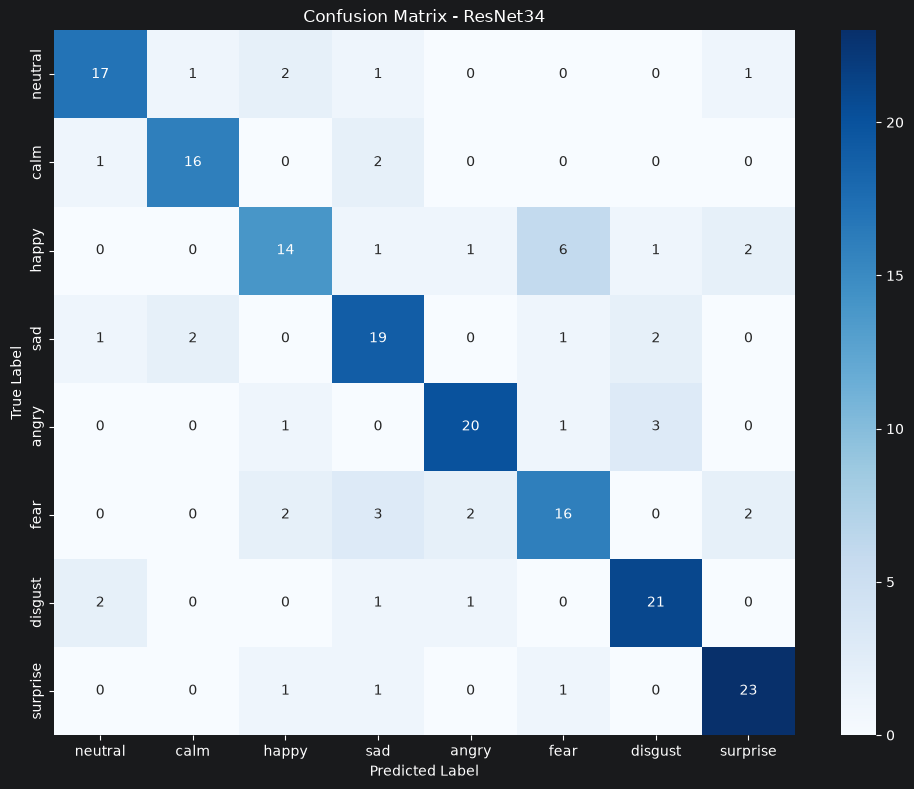

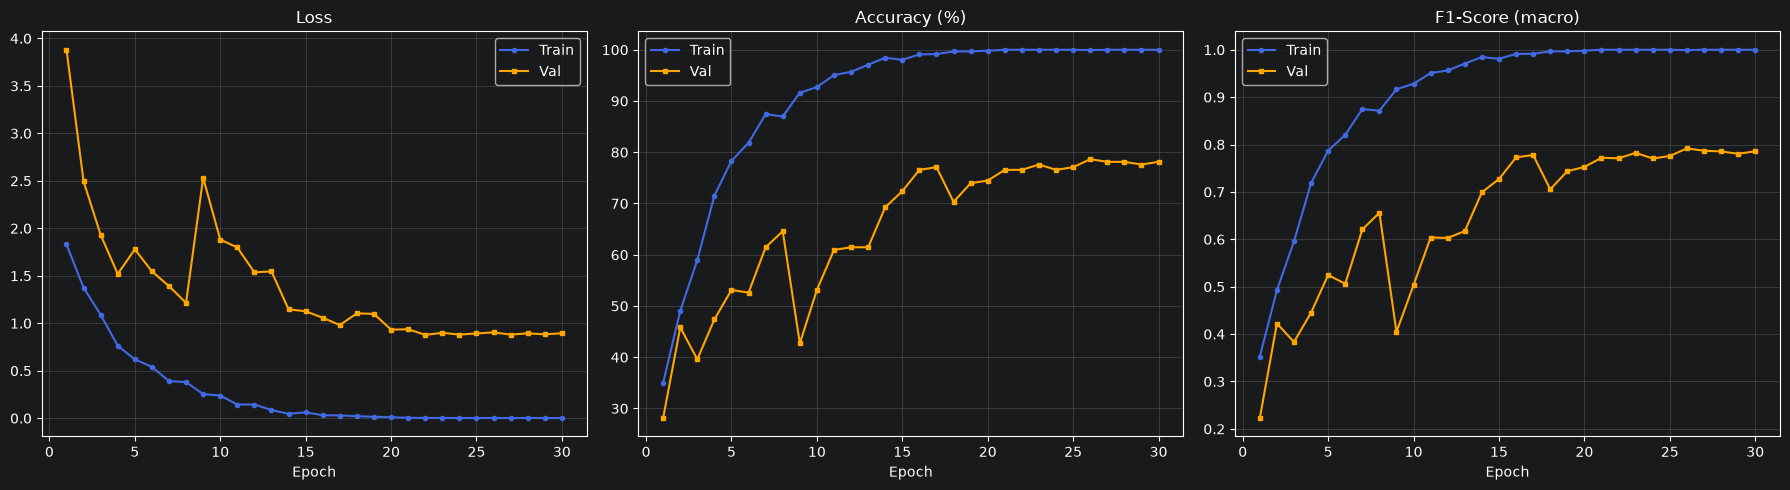

✓ Saved → results/training_curves_ResNet34.png
+------------+---------+----------+------------+
|   Split    | Samples | Accuracy | F1 (macro) |
+------------+---------+----------+------------+
|   Train    |   1536  | 100.00%  |   1.0000   |
| Validation |   192   |  76.56%  |   0.7709   |
|    Test    |   192   |  76.04%  |   0.7610   |
+------------+---------+----------+------------+

✓ Training completed successfully!
  Best checkpoint saved: checkpoints/ResNet34.pth
  Results visualizations: results/
Training: DenseNet121
Ep [01/30]  lr=1.00e-03  tr: L=1.7035 A=36.9% F1=0.3699  |  va: L=2.1187 A=27.1% F1=0.2234  ★
Ep [02/30]  lr=9.97e-04  tr: L=1.0876 A=59.8% F1=0.5994  |  va: L=1.4471 A=50.5% F1=0.4929  ★
Ep [03/30]  lr=9.89e-04  tr: L=0.8032 A=71.8% F1=0.7206  |  va: L=1.2741 A=63.0% F1=0.6300  ★
Ep [04/30]  lr=9.76e-04  tr: L=0.5277 A=81.6% F1=0.8173  |  va: L=1.1147 A=60.9% F1=0.6134  ★
Ep [05/30]  lr=9.57e-04  tr: L=0.4458 A=85.2% F1=0.8527  |  va: L=1.8415 A=49.5% F1=0.4531


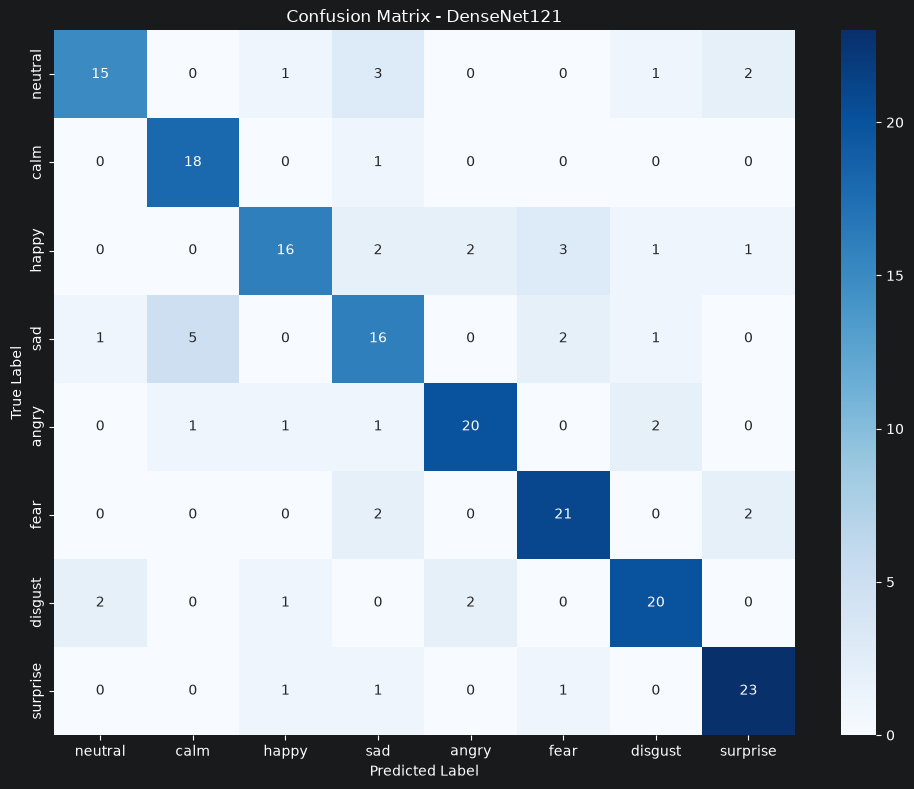

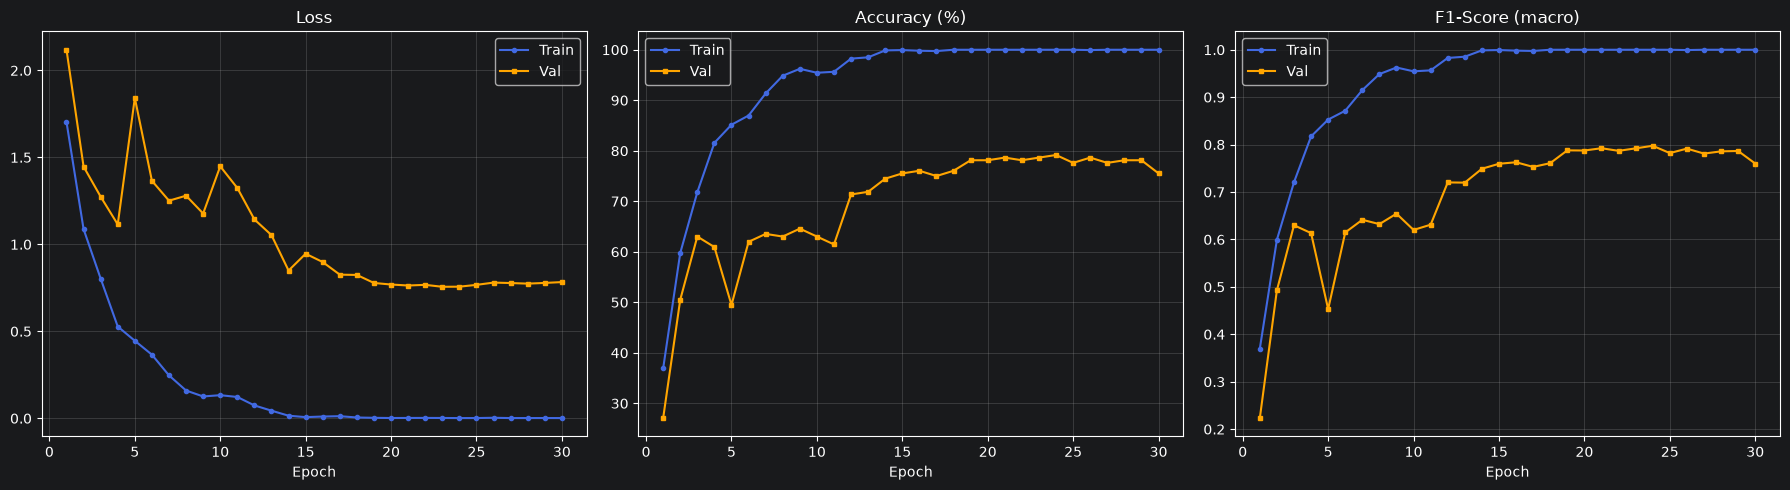

✓ Saved → results/training_curves_DenseNet121.png
+------------+---------+----------+------------+
|   Split    | Samples | Accuracy | F1 (macro) |
+------------+---------+----------+------------+
|   Train    |   1536  | 100.00%  |   1.0000   |
| Validation |   192   |  78.65%  |   0.7921   |
|    Test    |   192   |  77.60%  |   0.7752   |
+------------+---------+----------+------------+

✓ Training completed successfully!
  Best checkpoint saved: checkpoints/DenseNet121.pth
  Results visualizations: results/


In [13]:
results_summary = {}

# Dictionary của 3 builders
models_to_train = {
    "ResNet34": build_resnet34,
    "DenseNet121": build_densenet121,
}

for model_name, builder_fn in models_to_train.items():
    print(f"Training: {model_name}")

    # reset RNG each model
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    
    # Build model
    model = builder_fn()
    model = model.to(device)
    
    # Train
    model, history, test_metrics = finetune(
        model,
        train_loader, val_loader, test_loader,
        device,
        epochs=EPOCHS,
        lr=LR,
        verbose=True,
        checkpoint_dir=f"checkpoints/{model_name.replace(' ', '_')}"
    )
    
    # Store results
    results_summary[model_name] = {
        'history': history,
        'test_metrics': test_metrics,
        'model_state': model.state_dict()  # save weights
    }
    
    # Print classification report for test set
    get_test_report(label_names, test_metrics)
    
    # Plot confusion matrix for test set
    plot_confusion_matrix(test_metrics["targets"], test_metrics["preds"],
                        label_names, model_name)
    
    # Plot training curves
    get_training_curves(history, model_name)
    
    # Final summary
    get_summary(model, model_name, test_metrics)